In [9]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
from pathlib import Path

In [10]:
tickers = ["AAPL", "MSFT", "SPY"]
start_date = "2020-01-01"
end_date = "2025-01-01"

In [11]:
data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

close_prices = data["Close"].copy()
close_prices.head()

[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,MSFT,SPY
Date,,,
2020-01-02,72.400505,152.158371,296.888184
2020-01-03,71.696632,150.263748,294.640045
2020-01-06,72.267937,150.652176,295.764130
2020-01-07,71.928055,149.278549,294.932587
2020-01-08,73.085106,151.656357,296.504364


In [12]:
Path("../data/raw").mkdir(parents=True, exist_ok=True)
close_prices.to_csv("../data/raw/prices.csv")

In [14]:
returns = close_prices.pct_change().dropna()
returns.head()

Ticker,AAPL,MSFT,SPY
Date,,,
2020-01-03,-0.009722,-0.012452,-0.007572
2020-01-06,0.007968,0.002585,0.003815
2020-01-07,-0.004703,-0.009118,-0.002812
2020-01-08,0.016086,0.015929,0.005329
2020-01-09,0.021241,0.012493,0.006781


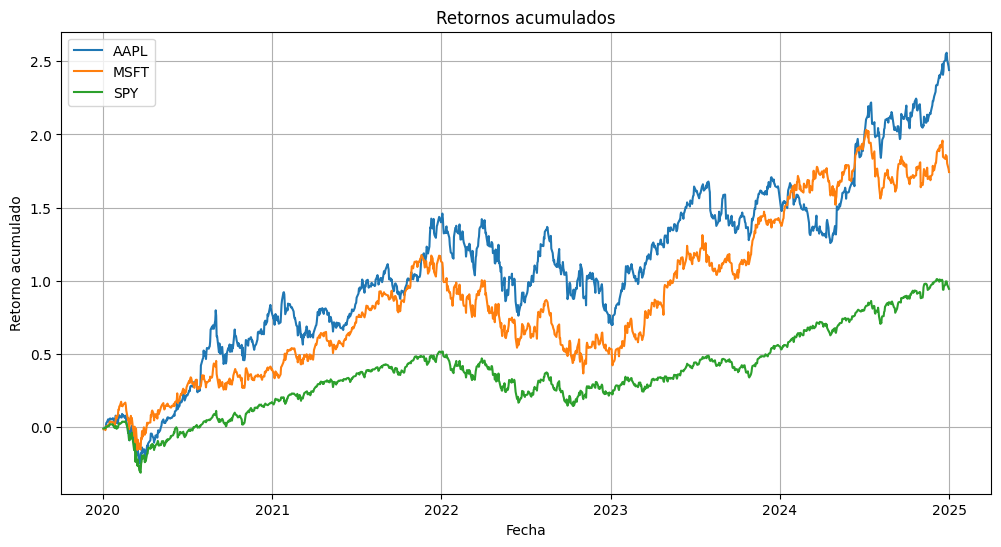

In [15]:
cum_returns = (1 + returns).cumprod() - 1

plt.figure(figsize=(12,6))
for col in cum_returns.columns:
    plt.plot(cum_returns.index, cum_returns[col], label=col)

plt.title("Retornos acumulados")
plt.xlabel("Fecha")
plt.ylabel("Retorno acumulado")
plt.legend()
plt.grid(True)
plt.show()

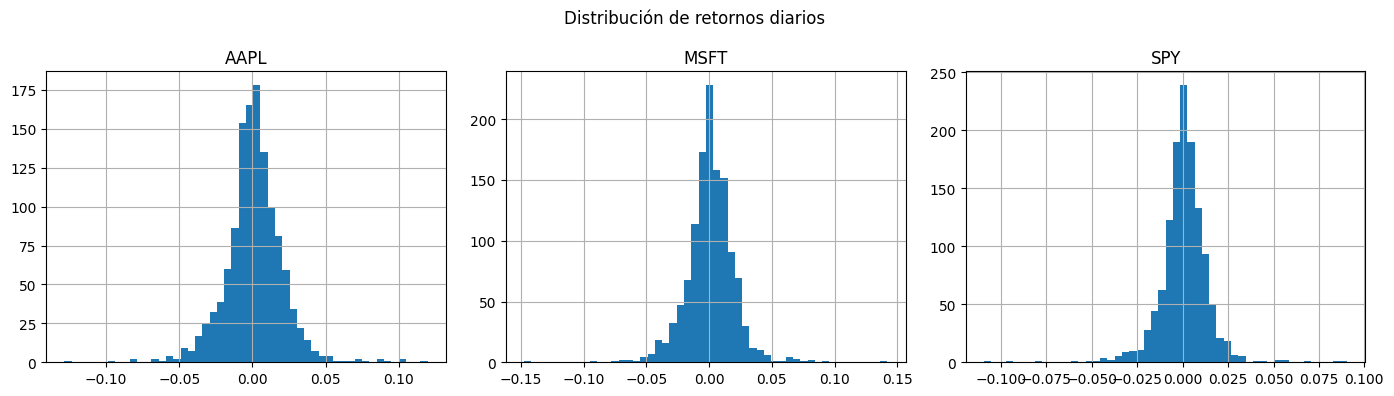

In [16]:
returns.hist(bins=50, figsize=(14,4), layout=(1, len(returns.columns)))
plt.suptitle("Distribución de retornos diarios")
plt.tight_layout()
plt.show()

In [17]:
quality_report = pd.DataFrame({
    "n_obs": close_prices.count(),
    "n_missing": close_prices.isna().sum(),
    "pct_missing": close_prices.isna().mean() * 100,
    "n_unique": close_prices.nunique(),
    "min_date": [close_prices[col].dropna().index.min() for col in close_prices.columns],
    "max_date": [close_prices[col].dropna().index.max() for col in close_prices.columns]
})

quality_report

,n_obs,n_missing,pct_missing,n_unique,min_date,max_date
Ticker,,,,,,
AAPL,1258,0,0.0,1243,2020-01-02,2024-12-31
MSFT,1258,0,0.0,1250,2020-01-02,2024-12-31
SPY,1258,0,0.0,1247,2020-01-02,2024-12-31


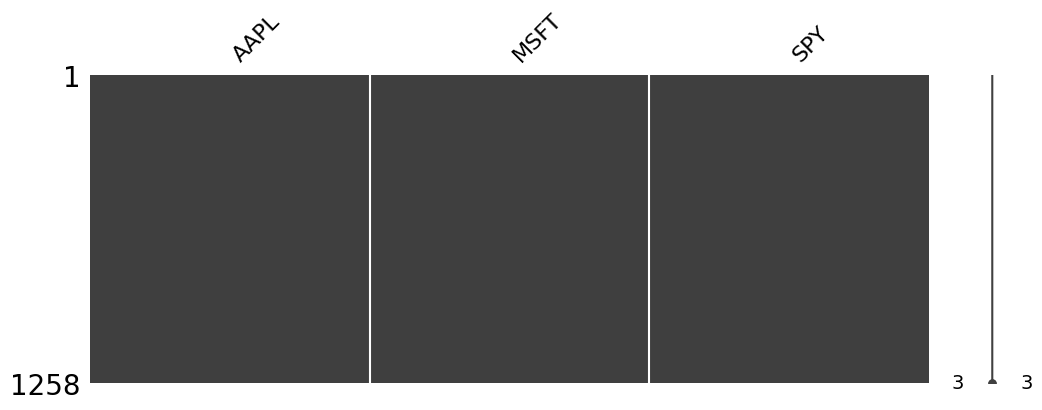

In [18]:
msno.matrix(close_prices, figsize=(12,4))
plt.show()